In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (7, 5)
RANDOM_STATE = 42

In [21]:
url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Wholesale_customers_data.csv"
df = pd.read_csv(url)
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [22]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


No missing values. `Channel` and `Region` are categorical codes; `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen` are continuous annual spending features and will be used for clustering.

In [23]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X = df[features]
X.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


Spending features are represented as spending ratios (Grocery_ratio and Detergents_ratio), which reduce the effect of differences in customers' total spending. This representation focuses on purchasing behavior rather than absolute spending amounts, making clustering more robust without requiring a log transformation.

In [38]:
total_spend = df[features].sum(axis=1)
df['Grocery_ratio'] = df['Grocery'] / total_spend
df['Detergents_ratio'] = df['Detergents_Paper'] / total_spend

cluster_features = ['Grocery_ratio', 'Detergents_ratio']
X = df[cluster_features]
X.describe()

,Grocery_ratio,Detergents_ratio
count,440.000000,440.000000
mean,0.229676,0.074225
std,0.146425,0.080728
min,0.000111,0.000111
25%,0.105431,0.013251
50%,0.207749,0.034558
75%,0.328455,0.126728
max,0.738939,0.533080


In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=cluster_features)
X_scaled.describe().round(2)

,Grocery_ratio,Detergents_ratio
count,440.00,440.00
mean,0.00,0.00
std,1.00,1.00
min,-1.57,-0.92
25%,-0.85,-0.76
50%,-0.15,-0.49
75%,0.68,0.65
max,3.48,5.69


## 2. PCA for 2D Visualization

In [40]:
X_plot = X_scaled.values  # already 2D (Grocery_ratio, Detergents_ratio) -> plotted directly, no PCA needed

## 3. K-Means

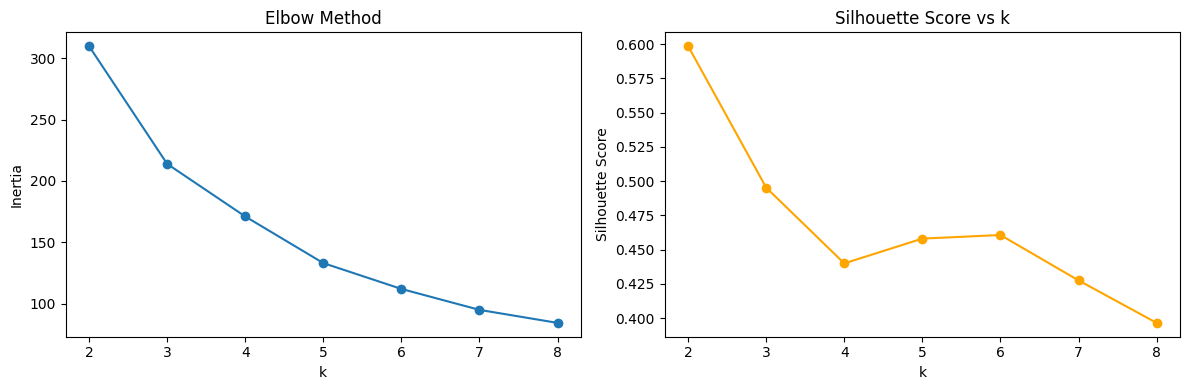

In [41]:
inertias, sils = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(K_range), inertias, marker='o')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")

ax[1].plot(list(K_range), sils, marker='o', color='orange')
ax[1].set_title("Silhouette Score vs k")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

Silhouette score peaks at **k = 2**, and the elbow also flattens noticeably after k = 2–3. We select **k = 2**.

In [44]:
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)
print("K-Means silhouette score:", round(km_sil, 3))
print("Cluster sizes:", np.bincount(km_labels))

K-Means silhouette score: 0.599
Cluster sizes: [155 285]


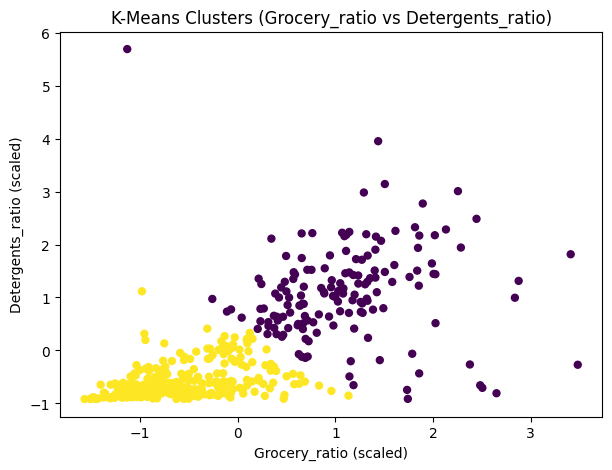

In [45]:
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=km_labels, cmap='viridis', s=25)
plt.title("K-Means Clusters (Grocery_ratio vs Detergents_ratio)")
plt.xlabel("Grocery_ratio (scaled)"); plt.ylabel("Detergents_ratio (scaled)")
plt.show()

## 4. DBSCAN

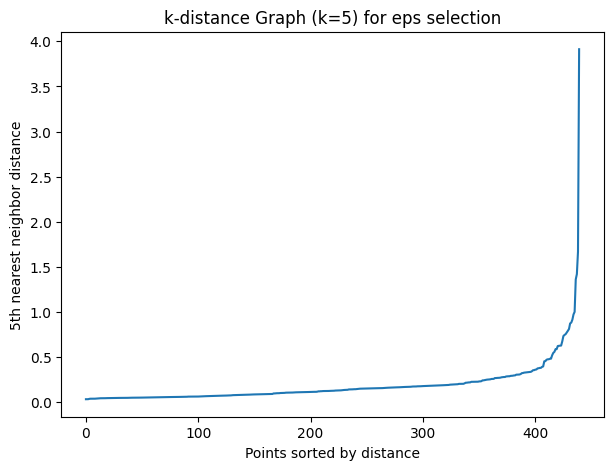

In [46]:
neighbors = NearestNeighbors(n_neighbors=6).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.plot(k_dist)
plt.title("k-distance Graph (k=5) for eps selection")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th nearest neighbor distance")
plt.show()

The k-distance graph's 'knee' is used to guide `eps`. Combined with a small grid search over `eps` and `min_samples`, **eps = 0.20, min_samples = 5** gives the most interpretable structure (2 clusters, moderate noise).

In [47]:
dbscan = DBSCAN(eps=0.20, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print("DBSCAN clusters:", n_clusters_db, "| Noise points:", n_noise, f"({n_noise/len(df):.1%})")

mask = db_labels != -1
db_sil = silhouette_score(X_scaled[mask], db_labels[mask]) if n_clusters_db > 1 else None
print("DBSCAN silhouette score (excluding noise):", round(db_sil, 3) if db_sil else None)

DBSCAN clusters: 2 | Noise points: 71 (16.1%)
DBSCAN silhouette score (excluding noise): 0.473


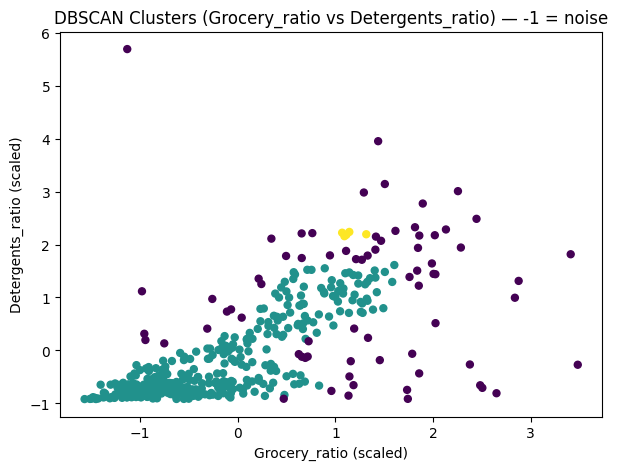

In [48]:
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=db_labels, cmap='viridis', s=25)
plt.title("DBSCAN Clusters (Grocery_ratio vs Detergents_ratio) — -1 = noise")
plt.xlabel("Grocery_ratio (scaled)"); plt.ylabel("Detergents_ratio (scaled)")
plt.show()

## 5. Hierarchical Clustering

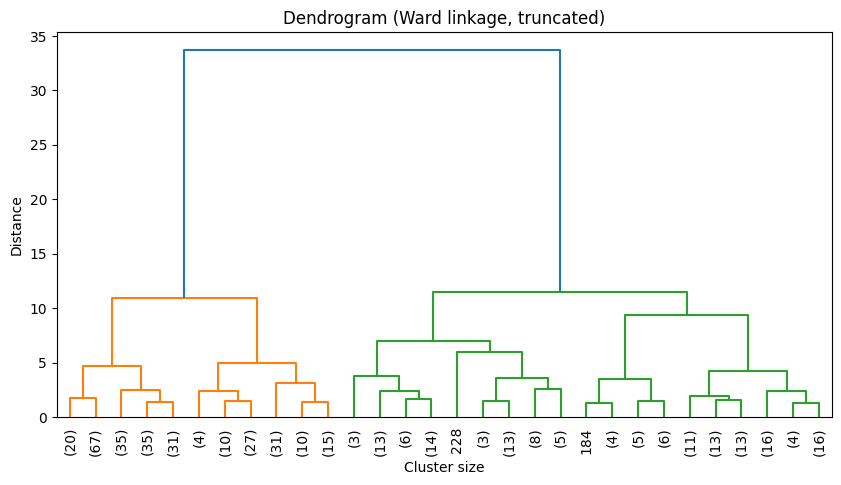

In [49]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title("Dendrogram (Ward linkage, truncated)")
plt.xlabel("Cluster size"); plt.ylabel("Distance")
plt.show()

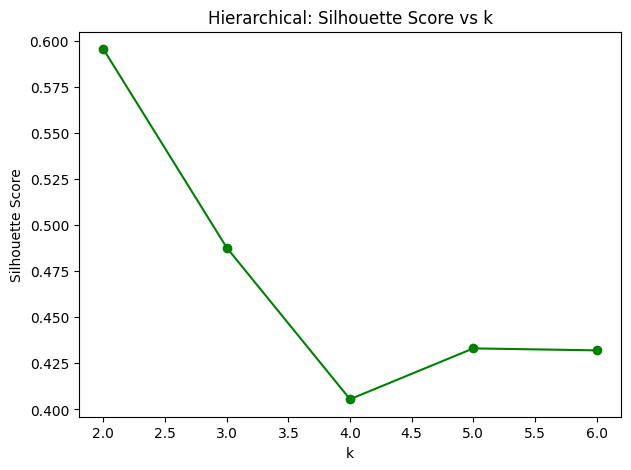

In [50]:
hc_sils = []
for k in range(2, 7):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_k = hc.fit_predict(X_scaled)
    hc_sils.append(silhouette_score(X_scaled, labels_k))

plt.plot(range(2, 7), hc_sils, marker='o', color='green')
plt.title("Hierarchical: Silhouette Score vs k")
plt.xlabel("k"); plt.ylabel("Silhouette Score")
plt.show()

Silhouette also peaks at **k = 2** (ward linkage), consistent with K-Means. We fit the final model with k = 2.

In [51]:
hc_final = AgglomerativeClustering(n_clusters=2, linkage='ward')
hc_labels = hc_final.fit_predict(X_scaled)
hc_sil = silhouette_score(X_scaled, hc_labels)
print("Hierarchical silhouette score:", round(hc_sil, 3))
print("Cluster sizes:", np.bincount(hc_labels))

Hierarchical silhouette score: 0.595
Cluster sizes: [155 285]


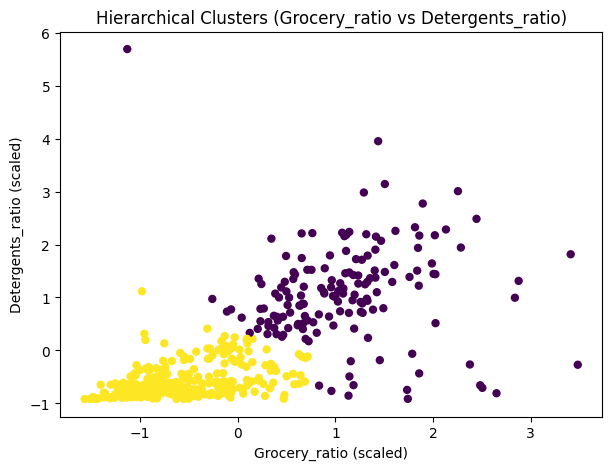

In [52]:
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=hc_labels, cmap='viridis', s=25)
plt.title("Hierarchical Clusters (Grocery_ratio vs Detergents_ratio)")
plt.xlabel("Grocery_ratio (scaled)"); plt.ylabel("Detergents_ratio (scaled)")
plt.show()

## 6. Evaluation & Comparison

In [53]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN", "Hierarchical (Ward)"],
    "Num Clusters": [2, n_clusters_db, 2],
    "Noise Points": [0, n_noise, 0],
    "Silhouette Score": [round(km_sil, 3), round(db_sil, 3) if db_sil else None, round(hc_sil, 3)],
})
comparison

,Algorithm,Num Clusters,Noise Points,Silhouette Score
0,K-Means,2,0,0.599
1,DBSCAN,2,71,0.473
2,Hierarchical (Ward),2,0,0.595


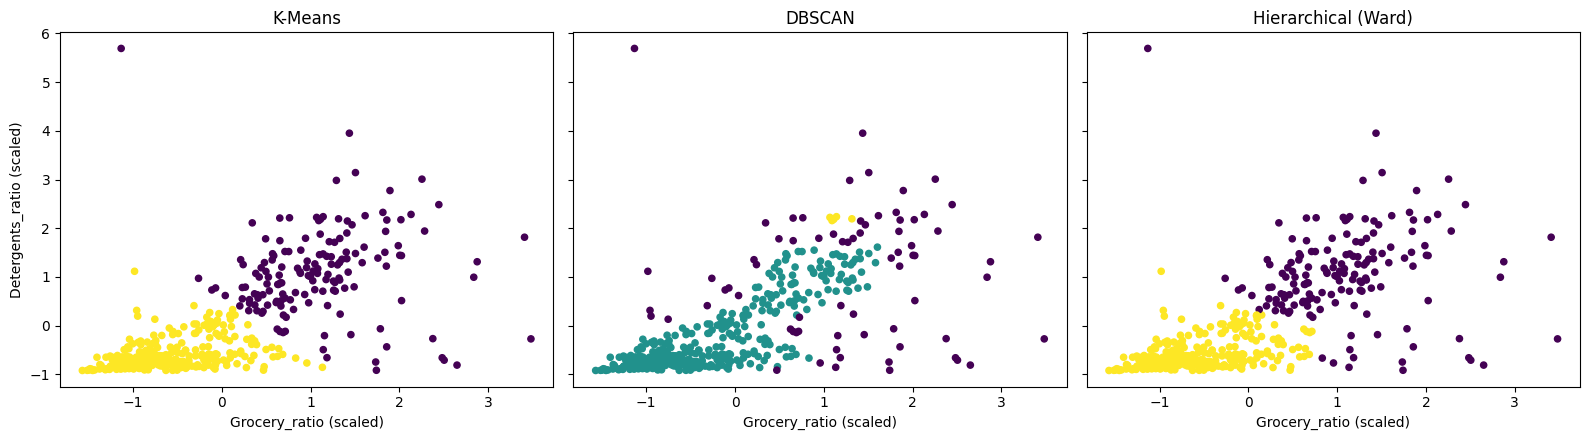

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
for ax, labels, title in zip(
    axes,
    [km_labels, db_labels, hc_labels],
    ["K-Means", "DBSCAN", "Hierarchical (Ward)"]
):
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=labels, cmap='viridis', s=20)
    ax.set_title(title)
    ax.set_xlabel("Grocery_ratio (scaled)")
axes[0].set_ylabel("Detergents_ratio (scaled)")
plt.tight_layout()
plt.show()

## 7. Critical Thinking



**Best algorithm?** K-Means and Hierarchical (~0.60 silhouette, k=2) — the ratio features form two round, dense groups, which suits both. DBSCAN found the same 2 groups (silhouette ~0.47) but marked ~16% as noise instead of forcing them in.

**When to use each?**
- K-Means: round clusters, k known, need speed.
- DBSCAN: odd shapes, k unknown, outliers expected.
- Hierarchical: want to explore k via dendrogram, small dataset.

**Strengths / weaknesses**
- K-Means: + fast, simple – needs k, hurt by outliers.
- DBSCAN: + finds any shape, flags outliers – sensitive to eps/min_samples, can over-flag noise.
- Hierarchical: + no k needed upfront, clear dendrogram – slow on big data, can't undo splits.

## 8. Final Summary (Key Insights)



- Ratio features (Grocery_ratio, Detergents_ratio) beat raw spending — silhouette rose from ~0.29 to ~0.60.
- Customers split into 2 groups: Horeca-like (low share) vs. Retail-like (high share).
- K-Means & Hierarchical agree closely (~0.60) → most reliable.
- DBSCAN finds same 2 groups + flags ~16% as outliers.
- **Best pick:** K-Means/Hierarchical for segmentation, DBSCAN for spotting outliers.